In [42]:
###Customer - income normalization (end to end) mini project
##Goal:
##Normalize `annual_income` so it becomes safe + useful for ML models.
## TARGET : target_sales

In [43]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

In [44]:
## Load dataset
df = pd.read_csv(r"C:\Data preprocessing\retail_sales_week4.csv")

In [45]:
## Check dataset
df.head()
df.isna().sum()

customer_id                  0
store_id                     0
age                          0
annual_income               59
monthly_spend                0
discount_percentage          0
purchase_frequency           0
avg_basket_value             0
avg_transaction_value        0
days_since_last_purchase     0
online_visits                0
total_returns                0
loyalty_score               40
marketing_spend             30
energy_consumption_store     0
target_sales                 0
dtype: int64

In [46]:
# define target columns and useless columns
TARGET = "target_sales"
ID_COLS = ["customer_ID", "store_id"]

In [47]:
# basic data cleaning
df_clean = df.copy()

df_clean.loc[df_clean['annual_income']<=0, 'annual_income'] = np.nan # income 0 or missing = missing
if "marketing_spend" in df_clean.columns:
    df_clean.loc[df_clean["marketing_spend"] < 0, "marketing_spend"] = np.nan # if marketing spend is negative, treat it as missing

In [48]:
##Define features
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
numeric_features = [c for c in numeric_cols if c not in ID_COLS + [TARGET]]
X = df_clean[numeric_features]
y = df_clean[TARGET]

In [49]:
## Train-test split 
X_train, X_test, y_train, y_test = train_test_split(X,y ,test_size=0.2,random_state=42)

In [50]:
##Diagnostics for annual_income (Train only)
income_train = X_train["annual_income"].copy()

print("INCOME DIAGNOSTICS (TRAIN)")
print("Missing %:", round(income_train.isna().mean() * 100, 2))
print("Skewness :", round(income_train.dropna().skew(), 3))
print("Mean     :", round(income_train.dropna().mean(), 2))
print("Median   :", round(income_train.dropna().median(), 2))

INCOME DIAGNOSTICS (TRAIN)
Missing %: 6.12
Skewness : 8.755
Mean     : 805713.26
Median   : 612665.3


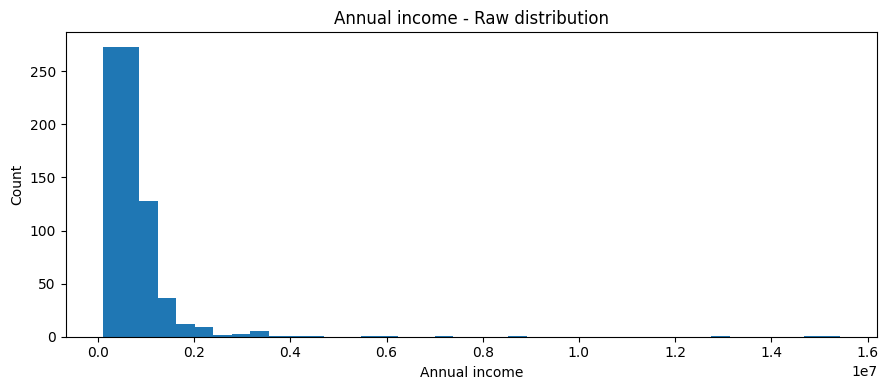

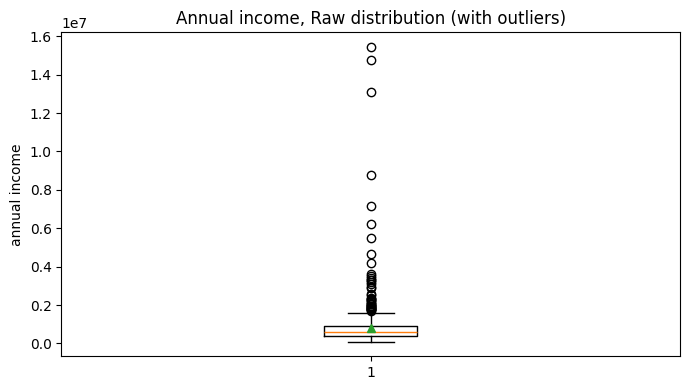

In [51]:
## Visualization
plt.figure(figsize =(9,4))
plt.hist(income_train.dropna(), bins = 40)
plt.title("Annual income - Raw distribution")
plt.xlabel("Annual income")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize = (7,4))
plt.boxplot(income_train.dropna(), showmeans=True)
plt.title("Annual income, Raw distribution (with outliers)")
plt.ylabel("annual income")
plt.tight_layout()
plt.show()

In [52]:
## We're going to build two basic approaches --> 
##   A) baseline = standard preprocessing using SimpleImputer and Scaler
##   B) Normalized method = special transformation on Annual_income only

In [53]:
## A) Baseline model (strategy = median)
baseline_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

baseline_model = Pipeline(steps=[
    ("preprocess", baseline_preprocess),
    ("model", Ridge(alpha=1.0, random_state= 40))]
)

In [54]:
## B) normalized methods 
## first option is using Log1p 
log1p_transform = FunctionTransformer(np.log1p)
income_pipeline_log = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", log1p_transform),
    ("scaler", StandardScaler())
])

## Second option we have is to use yeo-johnson method (Powertransform)
income_pipeline_power = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson", standardize=False)),
    ("scaler", StandardScaler())
])
others_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess_income_log = ColumnTransformer(
    transformers=[
        ("income", income_pipeline_log, income_col),
        ("others", others_pipeline, other_cols),
    ],
    remainder="drop"
)

preprocess_income_power = ColumnTransformer(
    transformers=[
        ("income", income_pipeline_power, income_col),
        ("others", others_pipeline, other_cols),
    ],
    remainder="drop"
)
model_income_log = Pipeline(steps=[
    ("preprocess", preprocess_income_log),
    ("model", Ridge(alpha=1.0, random_state=42))
])

model_income_power = Pipeline(steps=[
    ("preprocess", preprocess_income_power),
    ("model", Ridge(alpha=1.0, random_state=42))
])

In [55]:
## group columns 
income_col = ["annual_income"]
other_cols = [c for c in numeric_features if c != "annual_income"]

In [56]:
## Train model and evaluate MAE, R2 score
def evaluate(pipe):
    pipe.fit(X_train, y_train)
    pred_tr = pipe.predict(X_train)
    pred_te = pipe.predict(X_test)
    
    mae_tr = mean_absolute_error(y_train, pred_tr)
    mea_te = mean_absolute_error(y_test, pred_te)
    
    r2_tr = r2_score(y_train, pred_tr)
    r2_te = r2_score(y_test, pred_te)
    
    return pipe

In [57]:
def get_transformed_income(preprocessor: ColumnTransformer, X_in: pd.DataFrame):
    # Transform full matrix
    X_t = preprocessor.transform(X_in)
    # Income pipeline is first transformer and income has 1 column => it's column 0
    return X_t[:, 0]

# Fit preprocessors alone for visual validation
preprocess_income_log.fit(X_train, y_train)
preprocess_income_power.fit(X_train, y_train)


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('income', ...), ('others', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. 

In [58]:
baseline_model = evaluate(baseline_model)
model_income_log = evaluate(model_income_log)
model_income_power = evaluate(model_income_power)


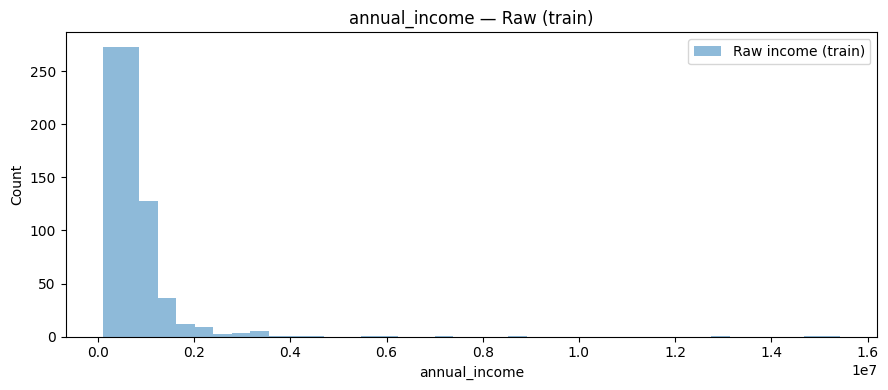

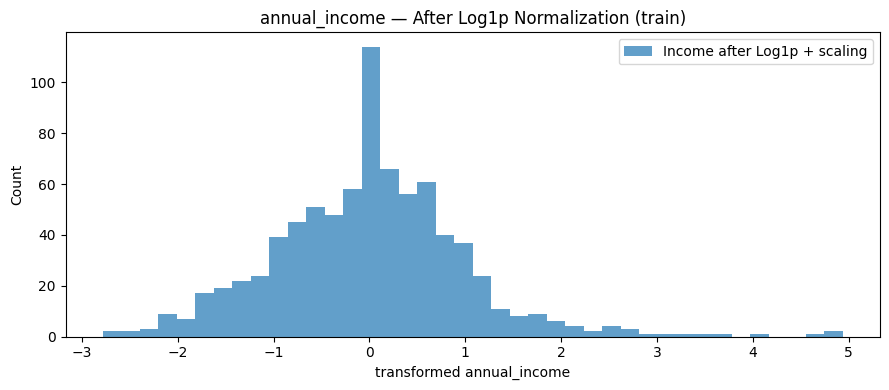

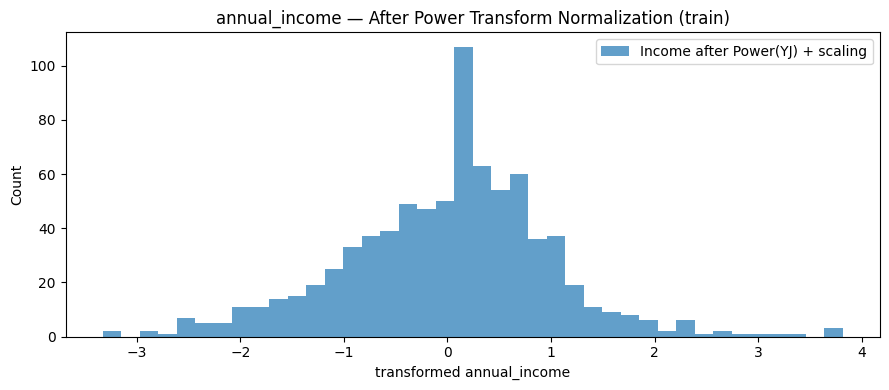

In [59]:
## HISTOGRAM COMPARISONS
income_log_vals = get_transformed_income(preprocess_income_log, X_train)
income_pow_vals = get_transformed_income(preprocess_income_power, X_train)


plt.figure(figsize=(9, 4))
plt.hist(income_train.dropna(), bins=40, alpha=0.5, label="Raw income (train)")
plt.title("annual_income — Raw (train)")
plt.xlabel("annual_income")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(income_log_vals, bins=40, alpha=0.7, label="Income after Log1p + scaling")
plt.title("annual_income — After Log1p Normalization (train)")
plt.xlabel("transformed annual_income")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(income_pow_vals, bins=40, alpha=0.7, label="Income after Power(YJ) + scaling")
plt.title("annual_income — After Power Transform Normalization (train)")
plt.xlabel("transformed annual_income")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


In [60]:
print("Project done")

Project done
